# Flowering Trends Analysis for *Arabidopsis thaliana*

This notebook analyzes occurrence-level flowering predictions with geographic and temporal context.  
We aim to capture important trends such as seasonal flowering patterns across latitude bands and regions.


In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load the occurrence-level analysis log
occurrence_log = pd.read_csv("occurrence_analysis_log.csv")

# Convert eventDate to datetime
occurrence_log['eventDate'] = pd.to_datetime(occurrence_log['eventDate'], errors='coerce')

# Display basic info about the dataset
print(f"Total occurrences: {len(occurrence_log)}")
print(f"Flowering occurrences: {(occurrence_log['predicted_label_occurrence'] == 'FL').sum()}")
print(f"Date range: {occurrence_log['year'].min():.0f} - {occurrence_log['year'].max():.0f}")

occurrence_log.head()

Total occurrences: 13255
Flowering occurrences: 11871
Date range: 1956 - 2025


,gbifID,predicted_label_occurrence,max_prob_flowering,num_images,year,month,day,decade,decimalLatitude,decimalLongitude,...,countryCode,stateProvince,county,locality,continent,eventDate,elevation,mean_prob_flowering,min_prob_flowering,observation_date
0,1262366711,FL,0.8057,1,2015.0,4.0,26.0,2010.0,60.578357,4.962685,...,NO,Hordaland,NaN,NaN,EUROPE,2015-04-26,NaN,0.8057,0.8057,2015-04-26
1,1453111463,FL,0.5493,2,2016.0,9.0,9.0,2010.0,54.380167,-2.906612,...,GB,England,NaN,NaN,EUROPE,NaT,NaN,0.5313,0.5133,2016-09-09
2,1457597111,FL,0.6169,1,2017.0,3.0,24.0,2010.0,51.491405,-0.129022,...,GB,England,NaN,NaN,EUROPE,NaT,NaN,0.6169,0.6169,2017-03-24
3,1500349626,FL,0.8437,3,2017.0,4.0,29.0,2010.0,49.587693,8.896236,...,DE,Hessen,NaN,NaN,EUROPE,NaT,NaN,0.6096,0.2505,2017-04-29
4,1703130146,FL,0.7149,4,2017.0,5.0,14.0,2010.0,54.626690,24.928892,...,LT,Vilniaus,NaN,NaN,EUROPE,NaT,NaN,0.5905,0.2666,2017-05-14


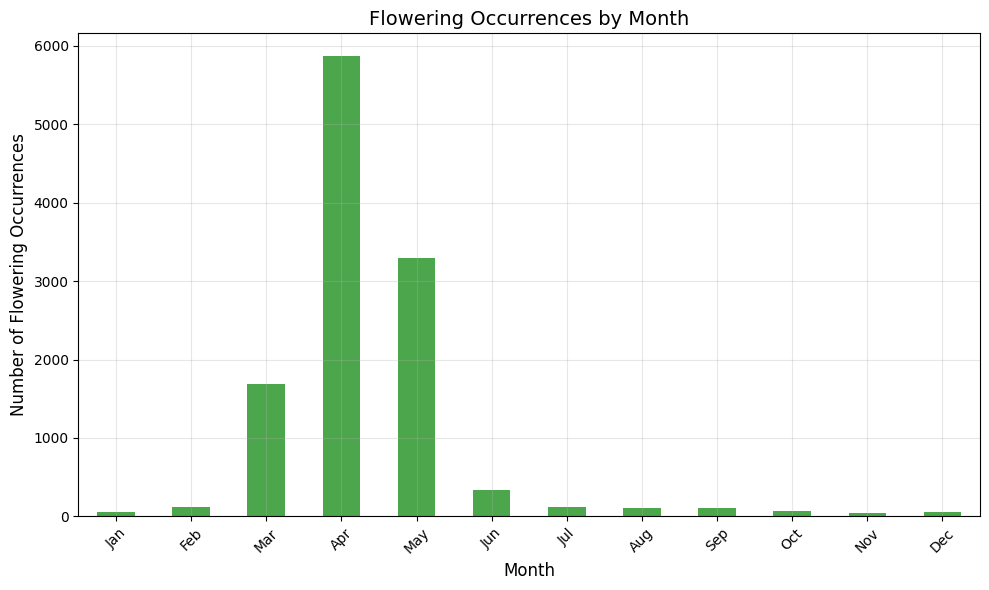

Peak flowering month: Apr (5867 occurrences)


In [17]:
# Flowering counts by month
flowering_records = occurrence_log[occurrence_log['predicted_label_occurrence'] == 'FL']

# Filter out records without month data
monthly_data = flowering_records[flowering_records['month'].notna()]

if len(monthly_data) > 0:
    monthly = monthly_data.groupby('month').size()
    
    # Create month names mapping
    month_names = {1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr', 5: 'May', 6: 'Jun',
                   7: 'Jul', 8: 'Aug', 9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dec'}
    
    # Convert index to month names
    monthly.index = monthly.index.map(month_names)
    
    plt.figure(figsize=(10,6))
    monthly.plot(kind='bar', color='green', alpha=0.7)
    plt.title("Flowering Occurrences by Month", fontsize=14)
    plt.xlabel("Month", fontsize=12)
    plt.ylabel("Number of Flowering Occurrences", fontsize=12)
    plt.xticks(rotation=45)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # Find peak month using original numeric data for indexing
    peak_month_num = monthly_data.groupby('month').size().idxmax()
    peak_count = monthly_data.groupby('month').size().max()
    peak_month_name = month_names[peak_month_num]
    print(f"Peak flowering month: {peak_month_name} ({peak_count} occurrences)")
else:
    print("No records with valid month data found")

<Figure size 1200x700 with 0 Axes>

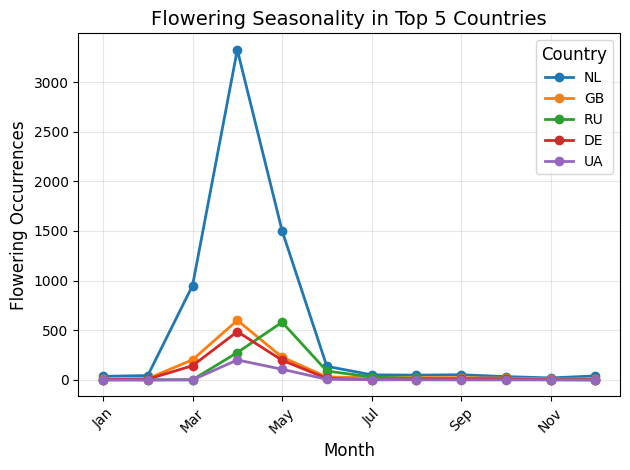

Top countries by flowering records:
countryCode
NL    6238
GB    1190
RU    1018
DE     877
UA     318
FR     309
AT     293
CZ     277
NO     259
DK     193
dtype: int64


In [18]:
# Regional trends (example: by country)
flowering_with_country = occurrence_log[
    (occurrence_log['predicted_label_occurrence'] == 'FL') & 
    (occurrence_log['month'].notna()) & 
    (occurrence_log['countryCode'].notna())
]

if len(flowering_with_country) > 0:
    country_monthly = (
        flowering_with_country
        .groupby(['month', 'countryCode'])
        .size()
        .unstack(fill_value=0)
    )
    
    # Plot top 5 countries by total flowering records
    top_countries = country_monthly.sum().sort_values(ascending=False).head(5).index
    
    # Create month names mapping
    month_names = {1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr', 5: 'May', 6: 'Jun',
                   7: 'Jul', 8: 'Aug', 9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dec'}
    
    # Convert index to month names
    country_monthly.index = country_monthly.index.map(month_names)
    
    plt.figure(figsize=(12,7))
    country_monthly[top_countries].plot(kind='line', marker='o', linewidth=2, markersize=6)
    plt.title("Flowering Seasonality in Top 5 Countries", fontsize=14)
    plt.xlabel("Month", fontsize=12)
    plt.ylabel("Flowering Occurrences", fontsize=12)
    plt.legend(title="Country", title_fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
    
    print("Top countries by flowering records:")
    # Use original numeric data for totals calculation
    original_country_monthly = (
        flowering_with_country
        .groupby(['month', 'countryCode'])
        .size()
        .unstack(fill_value=0)
    )
    country_totals = original_country_monthly.sum().sort_values(ascending=False)
    print(country_totals.head(10))
else:
    print("No flowering records with valid country and month data found")

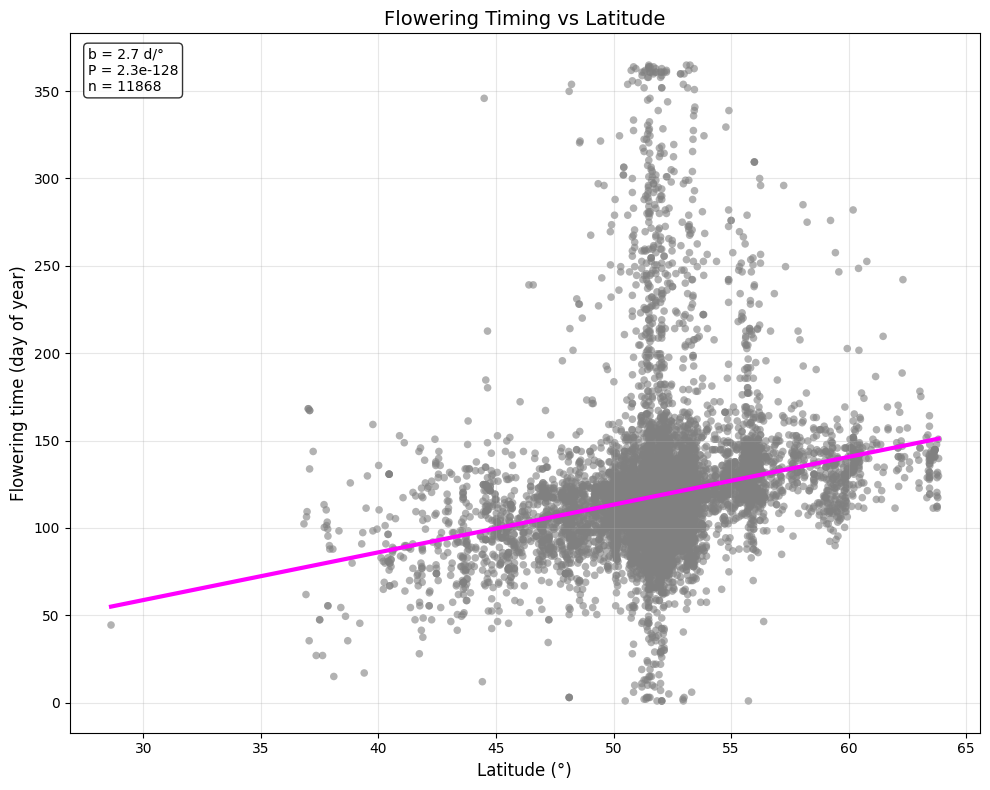

Linear Regression Results:
Slope: 2.73 days per degree latitude
R-squared: 0.048
P-value: 2.33e-128
Sample size: 11868 flowering records

🌸 Significant trend: Flowering occurs later at higher latitudes


In [19]:
# Linear regression: Flowering timing vs Latitude
from scipy import stats
import seaborn as sns

# Filter for flowering records with valid coordinates and day-of-year data
flowering_coords = occurrence_log[
    (occurrence_log['predicted_label_occurrence'] == 'FL') & 
    (occurrence_log['has_coordinates'] == True) & 
    (occurrence_log['month'].notna()) & 
    (occurrence_log['day'].notna())
].copy()

if len(flowering_coords) > 0:
    # Calculate day of year (approximate)
    flowering_coords['day_of_year'] = (flowering_coords['month'] - 1) * 30.44 + flowering_coords['day']
    
    # Remove outliers (keep reasonable range)
    lat_range = (flowering_coords['decimalLatitude'] >= 25) & (flowering_coords['decimalLatitude'] <= 70)
    day_range = (flowering_coords['day_of_year'] >= 1) & (flowering_coords['day_of_year'] <= 365)
    
    clean_data = flowering_coords[lat_range & day_range]
    
    if len(clean_data) > 10:  # Need enough points for meaningful regression
        # Perform linear regression
        slope, intercept, r_value, p_value, std_err = stats.linregress(
            clean_data['decimalLatitude'], 
            clean_data['day_of_year']
        )
        
        # Create the plot
        plt.figure(figsize=(10, 8))
        
        # Scatter plot
        plt.scatter(clean_data['decimalLatitude'], clean_data['day_of_year'], 
                   alpha=0.6, s=30, color='gray', edgecolors='none')
        
        # Regression line
        x_line = np.linspace(clean_data['decimalLatitude'].min(), 
                            clean_data['decimalLatitude'].max(), 100)
        y_line = slope * x_line + intercept
        plt.plot(x_line, y_line, color='magenta', linewidth=3)
        
        # Formatting
        plt.xlabel('Latitude (°)', fontsize=12)
        plt.ylabel('Flowering time (day of year)', fontsize=12)
        plt.title('Flowering Timing vs Latitude', fontsize=14)
        plt.grid(True, alpha=0.3)
        
        # Add regression statistics to plot
        stats_text = f'b = {slope:.1f} d/°\nP = {p_value:.1e}\nn = {len(clean_data)}'
        plt.text(0.02, 0.98, stats_text, transform=plt.gca().transAxes, 
                verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
        
        plt.tight_layout()
        plt.show()
        
        # Print detailed statistics
        print(f"Linear Regression Results:")
        print(f"Slope: {slope:.2f} days per degree latitude")
        print(f"R-squared: {r_value**2:.3f}")
        print(f"P-value: {p_value:.2e}")
        print(f"Sample size: {len(clean_data)} flowering records")
        
        if p_value < 0.05:
            direction = "later" if slope > 0 else "earlier"
            print(f"\n🌸 Significant trend: Flowering occurs {direction} at higher latitudes")
        else:
            print(f"\n📊 No significant relationship between latitude and flowering timing")
            
    else:
        print(f"Not enough data points for regression analysis (only {len(clean_data)} records)")
else:
    print("No flowering records with valid coordinates and timing data found")

C:\Users\abdul\AppData\Local\Temp\ipykernel_16460\1628188164.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  flowering_with_coords['lat_band'] = flowering_with_coords['decimalLatitude'].apply(latitude_band)


<Figure size 1200x700 with 0 Axes>

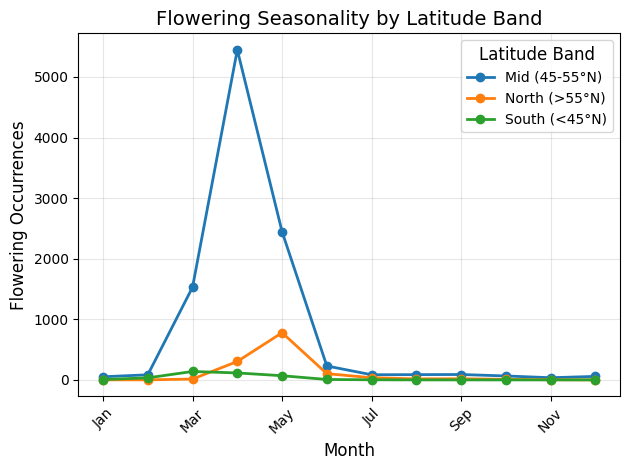

Records by latitude band:
lat_band
Mid (45-55°N)    10211
North (>55°N)     1286
South (<45°N)      373
Name: count, dtype: int64


In [20]:
# Split by latitude bands (e.g., South, Mid, North Europe)
def latitude_band(lat):
    if pd.isna(lat):
        return "Unknown"
    elif lat < 45:
        return "South (<45°N)"
    elif lat < 55:
        return "Mid (45-55°N)"
    else:
        return "North (>55°N)"

# Filter for records with valid coordinates and month data
flowering_with_coords = occurrence_log[
    (occurrence_log['predicted_label_occurrence'] == 'FL') & 
    (occurrence_log['has_coordinates'] == True) & 
    (occurrence_log['month'].notna())
]

if len(flowering_with_coords) > 0:
    flowering_with_coords['lat_band'] = flowering_with_coords['decimalLatitude'].apply(latitude_band)
    
    lat_monthly = (
        flowering_with_coords
        .groupby(['month', 'lat_band'])
        .size()
        .unstack(fill_value=0)
    )
    
    # Remove 'Unknown' column if it exists
    if 'Unknown' in lat_monthly.columns:
        lat_monthly = lat_monthly.drop('Unknown', axis=1)
    
    # Create month names mapping
    month_names = {1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr', 5: 'May', 6: 'Jun',
                   7: 'Jul', 8: 'Aug', 9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dec'}
    
    # Convert index to month names
    lat_monthly.index = lat_monthly.index.map(month_names)
    
    plt.figure(figsize=(12,7))
    lat_monthly.plot(kind='line', marker='o', linewidth=2, markersize=6)
    plt.title("Flowering Seasonality by Latitude Band", fontsize=14)
    plt.xlabel("Month", fontsize=12)
    plt.ylabel("Flowering Occurrences", fontsize=12)
    plt.legend(title="Latitude Band", title_fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
    
    print("Records by latitude band:")
    print(flowering_with_coords['lat_band'].value_counts())
else:
    print("No flowering records with valid coordinates and month data found")

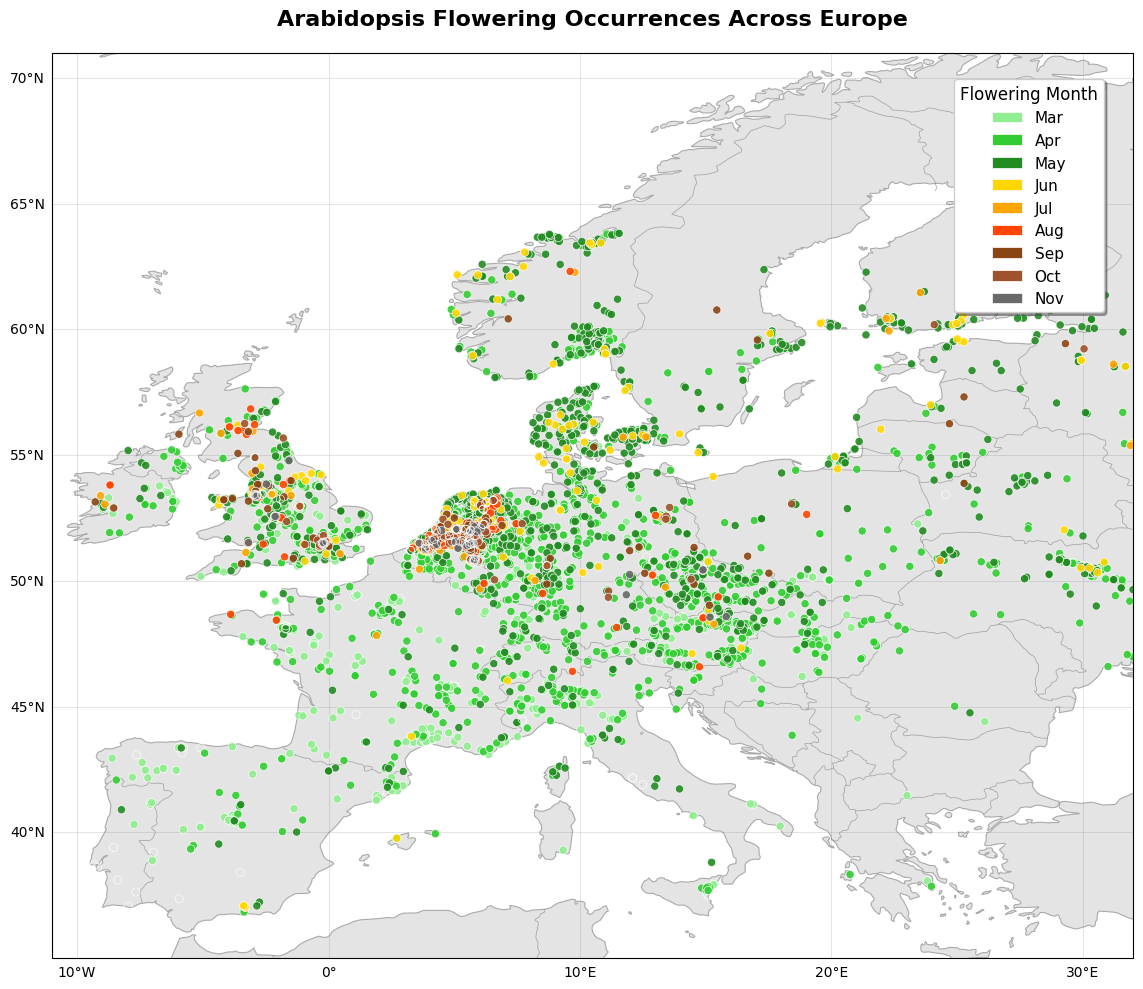

European Flowering Map Summary:
Total flowering records plotted: 10814
Latitude range: 36.8° to 63.8°N
Longitude range: -9.3° to 32.0°E
Countries represented: 36

Flowering records by month:
  Month 1: 59 records
  Month 2: 118 records
  Mar: 1681 records
  Apr: 5544 records
  May: 2720 records
  Jun: 255 records
  Jul: 93 records
  Aug: 88 records
  Sep: 96 records
  Oct: 65 records
  Nov: 36 records
  Month 12: 59 records


In [21]:
# Geographic Map of Flowering Occurrences in Europe
import matplotlib.patches as mpatches
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Filter for records with valid coordinates
flowering_coords_map = occurrence_log[
    (occurrence_log['predicted_label_occurrence'] == 'FL') & 
    (occurrence_log['has_coordinates'] == True) & 
    (occurrence_log['month'].notna())
].copy()

if len(flowering_coords_map) > 0:
    # Create month-based color mapping
    month_colors = {
        3: '#90EE90',   # Light green - March
        4: '#32CD32',   # Lime green - April  
        5: '#228B22',   # Forest green - May
        6: '#FFD700',   # Gold - June
        7: '#FFA500',   # Orange - July
        8: '#FF4500',   # Red orange - August
        9: '#8B4513',   # Saddle brown - September
        10: '#A0522D',  # Sienna - October
        11: '#696969'   # Dim gray - November
    }
    
    # Map colors to data
    flowering_coords_map['color'] = flowering_coords_map['month'].map(month_colors)
    
    # Focus on European extent
    europe_lat = (35, 71)  # Southern Spain to Northern Scandinavia
    europe_lon = (-11, 32)  # Western Ireland to Eastern Europe
    
    # Filter to European coordinates
    europe_mask = (
        (flowering_coords_map['decimalLatitude'] >= europe_lat[0]) & 
        (flowering_coords_map['decimalLatitude'] <= europe_lat[1]) &
        (flowering_coords_map['decimalLongitude'] >= europe_lon[0]) & 
        (flowering_coords_map['decimalLongitude'] <= europe_lon[1])
    )
    
    europe_data = flowering_coords_map[europe_mask]
    
    if len(europe_data) > 0:
        # Create map with cartopy
        fig, ax = plt.subplots(figsize=(14, 10), 
                              subplot_kw={'projection': ccrs.PlateCarree()})
        
        # Set extent for Europe
        ax.set_extent([europe_lon[0], europe_lon[1], europe_lat[0], europe_lat[1]], 
                     crs=ccrs.PlateCarree())
        
        # Add geographic features
        ax.add_feature(cfeature.LAND, facecolor='lightgray', alpha=0.6)
        ax.add_feature(cfeature.OCEAN, facecolor='white')
        ax.add_feature(cfeature.COASTLINE, edgecolor='darkgray', linewidth=0.8)
        ax.add_feature(cfeature.BORDERS, edgecolor='gray', linewidth=0.5, alpha=0.7)
        
        # Plot flowering occurrence points
        for month in sorted(europe_data['month'].unique()):
            month_data = europe_data[europe_data['month'] == month]
            if len(month_data) > 0:
                ax.scatter(month_data['decimalLongitude'], month_data['decimalLatitude'],
                          c=month_data['color'], s=35, alpha=0.9, edgecolors='white', linewidth=0.5,
                          transform=ccrs.PlateCarree(), zorder=5)
        
        # Add gridlines
        gl = ax.gridlines(draw_labels=True, dms=False, x_inline=False, y_inline=False,
                         linewidth=0.5, alpha=0.3, color='gray')
        gl.top_labels = False
        gl.right_labels = False
        gl.xlabel_style = {'size': 10}
        gl.ylabel_style = {'size': 10}
        
        # Title
        ax.set_title('Arabidopsis Flowering Occurrences Across Europe', 
                    fontsize=16, pad=20, weight='bold')
        
        # Custom legend for months
        legend_elements = []
        month_names = {3: 'Mar', 4: 'Apr', 5: 'May', 6: 'Jun', 
                      7: 'Jul', 8: 'Aug', 9: 'Sep', 10: 'Oct', 11: 'Nov'}
        
        for month in sorted(europe_data['month'].unique()):
            if month in month_colors:
                legend_elements.append(
                    mpatches.Circle((0, 0), 0.1, facecolor=month_colors[month], 
                                  edgecolor='white', linewidth=0.5,
                                  label=month_names.get(month, f'Month {int(month)}'))
                )
        
        # Position legend
        ax.legend(handles=legend_elements, loc='upper right', title='Flowering Month',
                 title_fontsize=12, fontsize=11, frameon=True, fancybox=True, shadow=True,
                 bbox_to_anchor=(0.98, 0.98))
        
        plt.tight_layout()
        plt.show()
        
        # Print summary statistics
        print(f"European Flowering Map Summary:")
        print(f"Total flowering records plotted: {len(europe_data)}")
        print(f"Latitude range: {europe_data['decimalLatitude'].min():.1f}° to {europe_data['decimalLatitude'].max():.1f}°N")
        print(f"Longitude range: {europe_data['decimalLongitude'].min():.1f}° to {europe_data['decimalLongitude'].max():.1f}°E")
        print(f"Countries represented: {europe_data['countryCode'].nunique()}")
        
        # Monthly distribution
        print(f"\nFlowering records by month:")
        monthly_counts = europe_data['month'].value_counts().sort_index()
        for month, count in monthly_counts.items():
            month_name = month_names.get(month, f'Month {int(month)}')
            print(f"  {month_name}: {count} records")
            
    else:
        print("No flowering records found within European coordinate range")
else:
    print("No flowering records with valid coordinates found")